# 04 — NFL Outcome Inventory + Hypothesis Discovery

**Purpose**:
1. Profile available NFL outcome metrics from player_play.
2. Link Combine movement features to NFL outcomes.
3. Rank hypothesis candidates.
4. Generate `outputs/reports/hypothesis_candidates.md`.

**Temporal boundary**: Combine features are prospective (pre-draft).
NFL outcomes are from the player's FIRST NFL season only.
This is the correct scouting interpretation.

> **Critical**: Do not claim causation. Report associations with appropriate caveats.

In [1]:
import sys
import logging
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ensure_dirs, FIGURES_DIR, TABLES_DIR, REPORTS_DIR
from src.config import COMBINE_FEATURES_PARQUET, PLAYER_MASTER_PARQUET, DATA_PROCESSED, MIN_SAMPLE_SIZE
from src.data_loading import load_players, load_combine_results, load_player_play
from src.player_mapping import (
    assign_position_groups, build_master_player_table,
    filter_to_first_season,
)
from src.nfl_features import (
    aggregate_nfl_metrics, wr_te_metrics, dl_edge_metrics, ol_metrics, db_metrics,
    compute_snap_counts,
)

from src.combine_features import aggregate_player_features
from src.statistics import (
    spearman_with_ci, build_correlation_summary, compare_groups,
    cohens_d, rank_biserial_r, incremental_r_squared,
)
from src.visualization import (
    plot_combine_vs_nfl, plot_correlation_heatmap,
    plot_model_comparison, plot_missing_data_heatmap,
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(name)s | %(message)s')
ensure_dirs()
print('Setup complete.')

Setup complete.


## 1. Load All Processed Data

In [2]:
# Load players
players = load_players()
players = assign_position_groups(players)
pos_map = players[['nfl_id', 'position', 'position_group']].drop_duplicates('nfl_id')

# Load combine features
if COMBINE_FEATURES_PARQUET.exists():
    features_df = pd.read_parquet(COMBINE_FEATURES_PARQUET)
    player_features = aggregate_player_features(features_df, agg_strategy='best_attempt')
    player_features = player_features.merge(pos_map, on='nfl_id', how='left')
    print(f'Combine features: {player_features.shape}')
else:
    print('WARNING: Run notebook 02 first to generate combine_features.parquet')
    player_features = pd.DataFrame()

# Load player-play data (NFL outcomes)
player_play = load_player_play()
print(f'player_play: {len(player_play):,} rows × {player_play.shape[1]} cols')
print(f'Unique players in player_play: {player_play["nfl_id"].nunique()}')

INFO | src.data_loading | Loaded players: 510 rows × 10 cols | 0.1 MB | source: players.csv
WARNING | src.data_loading | players — columns with missing values:
draft_round                127
draft_pick_within_round    127
draft_overall_pick         127
INFO | src.combine_features | aggregate_player_features (best_attempt): 1258 rows
WARNING | src.data_loading | player_play: requested columns not in file (skipped): ['position']


Combine features: (1258, 54)


INFO | src.data_loading | Loaded player_play: 314,197 rows × 19 cols | 65.5 MB | source: player_play.csv
WARNING | src.data_loading | player_play — columns with missing values:
rec_yards                     307937
yards_after_catch             307937
route_ran                     260889
separation_at_pass_forward    267460
cushion                       210445
expected_yards_after_catch    305221
pressure_allowed              253394
sack_allowed                  253394
time_to_pressure_allowed      309227
quick_pressure                310434
player_get_off                270195
sack                          227362
tackle                        302301
tackle_for_loss               302301
time_to_pressure              310393


player_play: 314,197 rows × 19 cols
Unique players in player_play: 497


## 2. NFL Outcome Profiling

Understand what metrics are available, how sparse they are, and what values are typical.

=== PLAYER PLAY — OUTCOME COLUMNS ===
Available columns: ['game_id', 'play_id', 'nfl_id', 'target', 'rec_yards', 'yards_after_catch', 'route_ran', 'separation_at_pass_forward', 'cushion', 'expected_yards_after_catch', 'pressure_allowed', 'sack_allowed', 'time_to_pressure_allowed', 'quick_pressure', 'player_get_off', 'sack', 'tackle', 'tackle_for_loss', 'time_to_pressure']

Outcome columns found in player_play: ['target', 'rec_yards', 'yards_after_catch', 'separation_at_pass_forward', 'cushion', 'expected_yards_after_catch', 'route_ran', 'player_get_off', 'sack', 'tackle', 'tackle_for_loss', 'time_to_pressure', 'quick_pressure', 'pressure_allowed', 'sack_allowed', 'time_to_pressure_allowed']

Missing rates (%) for outcome columns:


,missing_pct
quick_pressure,98.802344
time_to_pressure,98.789295
time_to_pressure_allowed,98.418190
rec_yards,98.007619
yards_after_catch,98.007619
expected_yards_after_catch,97.143194
tackle,96.213840
tackle_for_loss,96.213840
player_get_off,85.995411
separation_at_pass_forward,85.124938


INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\missing_nfl_outcomes.png


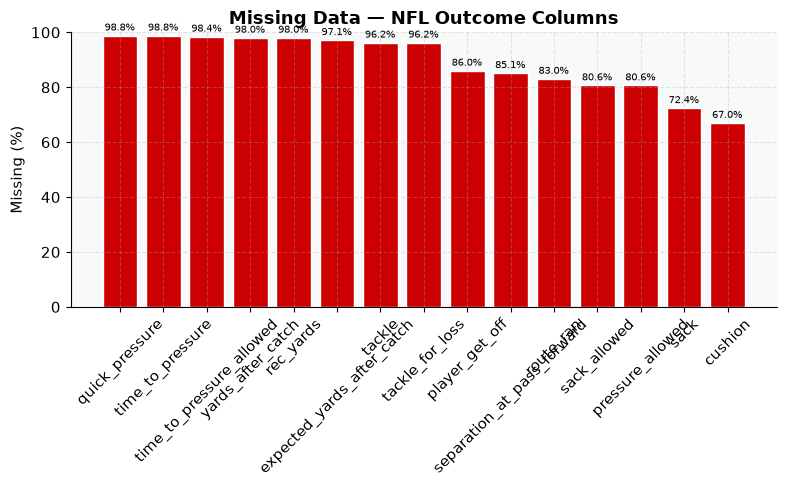

In [3]:
print('=== PLAYER PLAY — OUTCOME COLUMNS ===')
print(f'Available columns: {player_play.columns.tolist()}')
print()

# Missing rates for all potential outcome columns
outcome_candidates = [
    'target', 'rec_yards', 'yards_after_catch', 'separation_at_pass_forward',
    'cushion', 'expected_yards_after_catch', 'route_ran',
    'player_get_off', 'sack', 'tackle', 'tackle_for_loss',
    'time_to_pressure', 'quick_pressure',
    'pressure_allowed', 'sack_allowed', 'time_to_pressure_allowed',
]
available_outcomes = [c for c in outcome_candidates if c in player_play.columns]
print(f'Outcome columns found in player_play: {available_outcomes}')
print()

miss_pct = (player_play[available_outcomes].isnull().sum() / len(player_play) * 100).sort_values(ascending=False)
print('Missing rates (%) for outcome columns:')
display(miss_pct.to_frame('missing_pct'))

plot_missing_data_heatmap(
    player_play[available_outcomes],
    title='Missing Data — NFL Outcome Columns',
    filename='missing_nfl_outcomes.png',
)
plt.show()

In [4]:
# Numeric summary of outcome columns
print('Numeric summary of NFL outcome columns:')
display(player_play[available_outcomes].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

Numeric summary of NFL outcome columns:


,rec_yards,yards_after_catch,separation_at_pass_forward,cushion,expected_yards_after_catch,player_get_off,sack,tackle,time_to_pressure,sack_allowed,time_to_pressure_allowed
count,6260.000000,6260.000000,46737.000000,103752.000000,8976.000000,44002.000000,86835.000000,11896.000000,3804.000000,60803.000000,4970.000000
mean,12.009585,4.617732,3.115325,6.000563,4.178201,1.009683,0.005700,0.620124,2.992324,0.009638,3.029960
std,10.455739,6.290032,2.139706,2.952701,4.513684,0.293733,0.073035,0.485549,1.025714,0.094533,1.036045
min,-11.000000,-8.000000,0.092195,0.500000,0.010002,0.004000,0.000000,0.000000,0.800000,0.000000,0.900000
10%,3.000000,0.000000,0.900278,2.250000,0.336989,0.686000,0.000000,0.000000,2.000000,0.000000,2.000000
25%,5.000000,0.000000,1.397426,3.140000,0.951259,0.803000,0.000000,0.000000,2.300000,0.000000,2.400000
50%,9.000000,3.000000,2.619256,6.000000,2.708291,0.959000,0.000000,1.000000,2.800000,0.000000,2.800000
75%,16.000000,7.000000,4.316445,8.350000,5.811177,1.161000,0.000000,1.000000,3.400000,0.000000,3.400000
90%,25.000000,12.000000,5.992102,9.809000,9.997714,1.416000,0.000000,1.000000,4.300000,0.000000,4.400000
max,93.000000,76.000000,22.794132,20.280001,37.019997,2.000000,1.000000,2.000000,9.600000,1.000000,10.700000


## 3. Filter to First NFL Season

**Critical temporal boundary**: We only use outcomes from the player's FIRST NFL season.
This ensures a clean prospective scouting design.

In [5]:
# Try to determine season column
season_col = None
for col in ['season', 'year', 'gameYear']:
    if col in player_play.columns:
        season_col = col
        break

# If no season column, try extracting from game_id
if season_col is None and 'game_id' in player_play.columns:
    print('Extracting season from game_id...')
    sample_game_id = player_play['game_id'].dropna().iloc[0] if len(player_play) > 0 else ''
    print(f'Sample game_id: {sample_game_id}')
    # Common format: "2023_01_..." or "2023010100"
    player_play_copy = player_play.copy()
    player_play_copy['season'] = player_play_copy['game_id'].astype(str).str[:4]
    # Validate it looks like a year
    year_vals = player_play_copy['season'].unique()
    print(f'Extracted year values: {year_vals[:10]}')
    if all(str(y).isdigit() and 2000 <= int(y) <= 2030 for y in year_vals if str(y) != 'nan'):
        player_play = player_play_copy
        season_col = 'season'
        print(f'Season column created: {player_play["season"].value_counts().to_dict()}')
    else:
        print('Could not reliably extract season from game_id')

print(f'Season column used: {season_col}')

Extracting season from game_id...
Sample game_id: 2025111610
Extracted year values: <ArrowStringArray>
['2025', '2026', '2023', '2024']
Length: 4, dtype: str
Season column created: {'2025': 150425, '2024': 102467, '2023': 46484, '2026': 14821}
Season column used: season


In [6]:
# Filter to first season
if season_col is not None:
    player_play_first = filter_to_first_season(player_play, season_col=season_col)
    print(f'First-season plays: {len(player_play_first):,} rows | {player_play_first["nfl_id"].nunique()} players')
else:
    print('WARNING: Could not identify season column — using ALL plays (not first season only)')
    print('This may include multiple seasons. Interpret results with caution.')
    player_play_first = player_play

# Add position to player_play
player_play_first = player_play_first.merge(pos_map, on='nfl_id', how='left')

print(f'\nPosition distribution in first-season plays:')
if 'position' in player_play_first.columns:
    display(player_play_first['position'].value_counts().to_frame())

INFO | src.player_mapping | map_first_nfl_season: 497 players with season data
INFO | src.player_mapping | filter_to_first_season: 314,197 → 146,645 rows (497 players)


First-season plays: 146,645 rows | 497 players

Position distribution in first-season plays:


,count
position,
T,23167
G,22718
CB,21385
WR,19427
DT,10951
SS,10268
DE,9284
OLB,8582
FS,7045


## 4. Aggregate NFL Metrics to Player Level

In [7]:
nfl_metrics = aggregate_nfl_metrics(
    player_play=player_play_first,
    players=players,
    season_col=season_col,
    first_season_only=False,  # Already filtered above
)
print(f'Player-level NFL metrics: {nfl_metrics.shape}')
display(nfl_metrics.head())

# Snap counts (important confounder)
snap_counts = compute_snap_counts(player_play_first, season_col=season_col)
nfl_metrics = nfl_metrics.merge(snap_counts.rename(columns={'n_snaps': 'first_season_snaps'}), on='nfl_id', how='left')
print(f'\nSnap count distribution:')
display(nfl_metrics['first_season_snaps'].describe())

# Save
nfl_metrics.to_parquet(DATA_PROCESSED / 'nfl_metrics.parquet', index=False)
print('Saved: nfl_metrics.parquet')

INFO | src.nfl_features | aggregate_nfl_metrics complete: 497 rows | 497 unique players


Player-level NFL metrics: (497, 38)


,nfl_id,season,position,position_group,n_plays,n_sacks,sack_rate,n_quick_pressure,quick_pressure_rate,mean_time_to_pressure,...,mean_yac,median_yac,mean_separation,median_separation,pct_top_quartile_separation,n_separation_obs,mean_cushion,mean_expected_yac,yac_over_expected,n_qb_pressures
0,55867,2023,DE,edge,623,8.0,0.012841,35.0,0.056180,2.714286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,55870,2023,T,ol,1090,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,55874,2023,T,ol,1088,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,55875,2023,G,ol,864,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,55877,2023,DE,edge,403,3.0,0.007444,3.0,0.007444,3.206250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


INFO | src.nfl_features | compute_snap_counts: 497 player-season rows



Snap count distribution:


count     497.000000
mean      295.060362
std       289.534729
min         1.000000
25%        82.000000
50%       177.000000
75%       416.000000
max      1166.000000
Name: first_season_snaps, dtype: float64

Saved: nfl_metrics.parquet


## 5. Build Analysis Dataset

Join combine features + NFL metrics at the player level.
This is the core dataset for hypothesis discovery.

In [8]:
if not player_features.empty:
    # Pivot combine features wide (one row per player, columns per drill)
    feat_cols = [c for c in player_features.columns if c not in ['nfl_id', 'drill_type', 'attempt', 'position', 'position_group']]
    if 'drill_type' in player_features.columns:
        feat_wide = player_features.pivot_table(
            index='nfl_id', columns='drill_type', values=feat_cols, aggfunc='first'
        )
        feat_wide.columns = ['_'.join(map(str, c)).strip() for c in feat_wide.columns]
        feat_wide = feat_wide.reset_index()
    else:
        feat_wide = player_features.drop(columns=['attempt'], errors='ignore')

    # Join
    analysis_df = nfl_metrics.merge(feat_wide, on='nfl_id', how='inner')
    analysis_df = analysis_df.merge(pos_map, on='nfl_id', how='left', suffixes=('', '_pos'))

    print(f'Analysis dataset: {analysis_df.shape}')
    print(f'Unique players: {analysis_df["nfl_id"].nunique()}')
    print(f'Position groups present: {analysis_df["position_group"].value_counts().to_dict() if "position_group" in analysis_df.columns else "N/A"}')

    analysis_df.to_parquet(DATA_PROCESSED / 'analysis_dataset.parquet', index=False)
    print('Saved: analysis_dataset.parquet')
else:
    print('Combine features not available — run notebook 02 first.')
    analysis_df = pd.DataFrame()

Analysis dataset: (497, 374)
Unique players: 497
Position groups present: {'skill_offense': 143, 'ol': 120, 'edge': 63, 'cb': 63, 'safety': 52, 'dt': 52, 'rb': 2, 'lb': 2}
Saved: analysis_dataset.parquet


## 6. Correlation Discovery: Combine → NFL Outcomes

For each position group, compute Spearman correlations between
combine movement features and NFL outcome metrics.

In [9]:
# Define which outcome metrics are relevant per position group
POSITION_OUTCOME_MAP = {
    'WR':    ['mean_separation', 'median_separation', 'mean_yac', 'yac_over_expected', 'target_share'],
    'TE':    ['mean_separation', 'mean_yac', 'yards_per_reception', 'target_share'],
    'Edge':  ['mean_get_off', 'quick_pressure_rate', 'sack_rate', 'mean_time_to_pressure'],
    'DT':    ['quick_pressure_rate', 'sack_rate', 'n_tfl'],
    'OL':    ['pressure_allowed_rate', 'sack_allowed_rate'],
    'CB':    ['n_tackles'],
    'S':     ['n_tackles'],
    'RB':    ['mean_yac', 'yards_per_reception'],
}

all_correlations = []

if not analysis_df.empty and 'position_group' in analysis_df.columns:
    for pos_group, outcomes in POSITION_OUTCOME_MAP.items():
        group_data = analysis_df[analysis_df['position_group_pos'] == pos_group].copy()

        n = group_data['nfl_id'].nunique()

        if n < MIN_SAMPLE_SIZE:
            print(f'{pos_group}: SKIP (n={n} < {MIN_SAMPLE_SIZE})')
            continue

        print(f'\n=== {pos_group} (n={n}) ===')

        # Available combine features for this group
        combine_feats = [c for c in group_data.columns
                         if any(c.startswith(f) for f in [
                             'max_speed', 'first_step', 'total_direction', 'movement_efficiency',
                             'best_peak_reaccel', 'time_to_75pct', 'direction_change_rate',
                             'n_cut_sequences', 'mean_deceleration', 'burst_impulse',
                             'mean_speed',
                         ])]

        avail_outcomes = [c for c in outcomes if c in group_data.columns]

        if not combine_feats or not avail_outcomes:
            print(f'  No valid features/outcomes available')
            continue

        corr_summary = build_correlation_summary(
            group_data, combine_feats, avail_outcomes, method='spearman', min_n=MIN_SAMPLE_SIZE
        )
        corr_summary['position_group'] = pos_group
        all_correlations.append(corr_summary)

        if not corr_summary.empty:
            print(f'Top correlations (n={n}):')
            display(corr_summary.head(10))
else:
    print('Analysis dataset not available or no position_group column.')


=== WR (n=105) ===


C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:449: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = scipy_stats.spearmanr(valid[c], valid[o])
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:449: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = scipy_stats.spearmanr(valid[c], valid[o])
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:449: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = scipy_stats.spearmanr(valid[c], valid[o])
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:449: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = scipy_stats.spearmanr(valid[c], valid[o])
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\s

Top correlations (n=105):


,combine_feature,nfl_outcome,rho,abs_rho,p_value,n,significant,position_group
0,direction_change_rate_SHORT_SHUTTLE,mean_separation,-0.645190,0.645190,0.000210,28,True,WR
1,direction_change_rate_SHORT_SHUTTLE,median_separation,-0.509154,0.509154,0.005655,28,True,WR
2,time_to_75pct_peak_SHORT_SHUTTLE,mean_separation,0.494156,0.494156,0.007523,28,True,WR
3,time_to_75pct_peak_SHORT_SHUTTLE,median_separation,0.426543,0.426543,0.023603,28,True,WR
4,time_to_75pct_peak_THREE_CONE_DRILL,target_share,-0.395340,0.395340,0.061882,23,False,WR
5,movement_efficiency_SHORT_SHUTTLE,mean_separation,0.384784,0.384784,0.043191,28,True,WR
6,burst_impulse_0_1s_SHORT_SHUTTLE,mean_yac,-0.373855,0.373855,0.054732,27,False,WR
7,mean_speed_SHORT_SHUTTLE,mean_yac,-0.347587,0.347587,0.075648,27,False,WR
8,max_speed_FORTY_YARD_DASH,yac_over_expected,-0.338053,0.338053,0.001276,88,True,WR
9,movement_efficiency_THREE_CONE_DRILL,median_separation,0.336957,0.336957,0.115892,23,False,WR



=== TE (n=38) ===


...


=== S (n=52) ===


C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:449: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = scipy_stats.spearmanr(valid[c], valid[o])
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:449: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = scipy_stats.spearmanr(valid[c], valid[o])
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:449: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = scipy_stats.spearmanr(valid[c], valid[o])
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:449: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = scipy_stats.spearmanr(valid[c], valid[o])
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\s

Top correlations (n=52):


,combine_feature,nfl_outcome,rho,abs_rho,p_value,n,significant,position_group
0,mean_speed_THREE_CONE_DRILL,n_tackles,-0.871231,0.871231,0.001027,10,True,S
1,time_to_75pct_peak_THREE_CONE_DRILL,n_tackles,0.778259,0.778259,0.008014,10,True,S
2,max_speed_THREE_CONE_DRILL,n_tackles,-0.754658,0.754658,0.011645,10,True,S
3,max_speed_FORTY_YARD_DASH,n_tackles,0.443084,0.443084,0.002924,43,True,S
4,burst_impulse_0_5s_THREE_CONE_DRILL,n_tackles,-0.392668,0.392668,0.261678,10,False,S
5,first_step_acceleration_THREE_CONE_DRILL,n_tackles,-0.392668,0.392668,0.261678,10,False,S
6,total_direction_change_SKILL_DRILLS_DB,n_tackles,-0.368079,0.368079,0.007873,51,True,S
7,total_direction_change_FORTY_YARD_DASH,n_tackles,0.353990,0.353990,0.019868,43,True,S
8,first_step_acceleration_SHORT_SHUTTLE,n_tackles,-0.353226,0.353226,0.286616,11,False,S
9,burst_impulse_0_5s_SHORT_SHUTTLE,n_tackles,-0.353226,0.353226,0.286616,11,False,S


RB: SKIP (n=2 < 10)



=== TOP 20 COMBINE → NFL CORRELATIONS (across all positions) ===


,combine_feature,nfl_outcome,rho,abs_rho,p_value,n,significant,position_group
760,mean_speed_THREE_CONE_DRILL,n_tackles,-0.871231,0.871231,0.001027,10,True,S
761,time_to_75pct_peak_THREE_CONE_DRILL,n_tackles,0.778259,0.778259,0.008014,10,True,S
762,max_speed_THREE_CONE_DRILL,n_tackles,-0.754658,0.754658,0.011645,10,True,S
0,direction_change_rate_SHORT_SHUTTLE,mean_separation,-0.645190,0.645190,0.000210,28,True,WR
200,time_to_75pct_peak_THREE_CONE_DRILL,target_share,-0.574805,0.574805,0.015793,17,True,TE
720,max_speed_SHORT_SHUTTLE,n_tackles,0.566578,0.566578,0.027655,15,True,CB
721,mean_speed_THREE_CONE_DRILL,n_tackles,0.556919,0.556919,0.059984,12,False,CB
520,mean_speed_SHORT_SHUTTLE,quick_pressure_rate,0.526885,0.526885,0.043588,15,True,DT
722,time_to_75pct_peak_THREE_CONE_DRILL,n_tackles,-0.523983,0.523983,0.080355,12,False,CB
521,movement_efficiency_SHORT_SHUTTLE,sack_rate,-0.513707,0.513707,0.041810,16,True,DT


Saved correlation summary.


C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_S_mean_speed_THREE_CONE_DRILL_vs_n_tackles.png


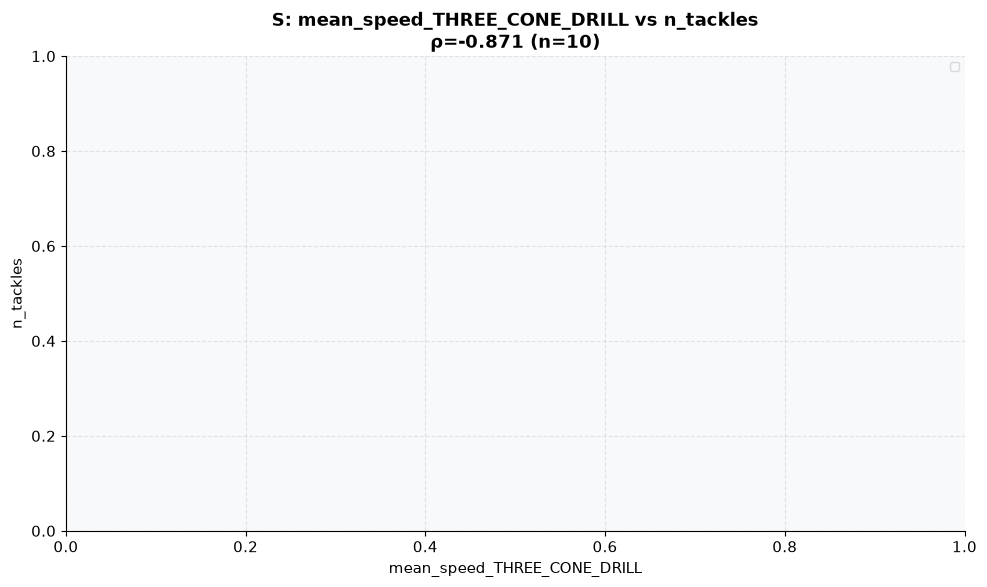

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_S_time_to_75pct_peak_THREE_CONE_DRILL_vs_n_tackles.png


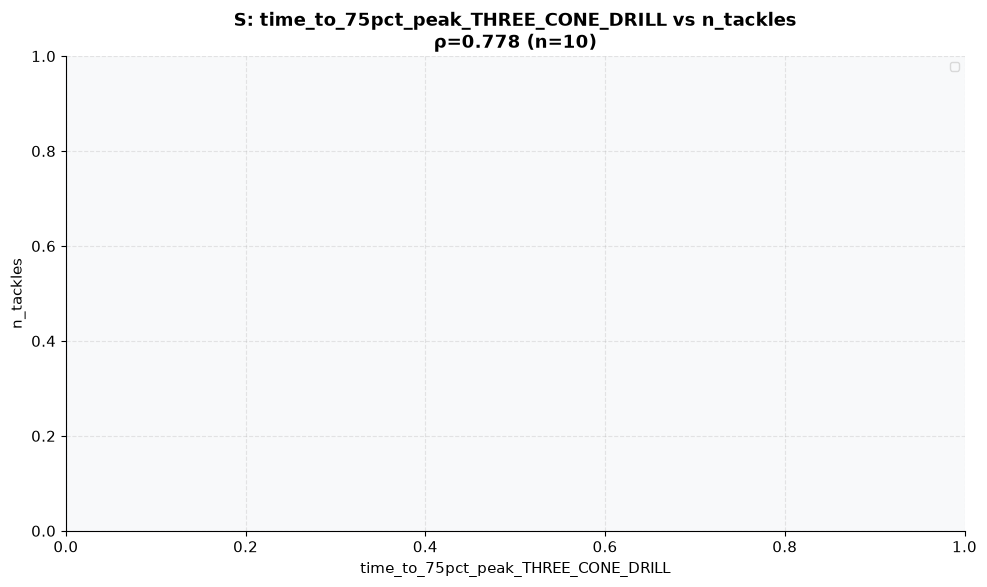

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_S_max_speed_THREE_CONE_DRILL_vs_n_tackles.png


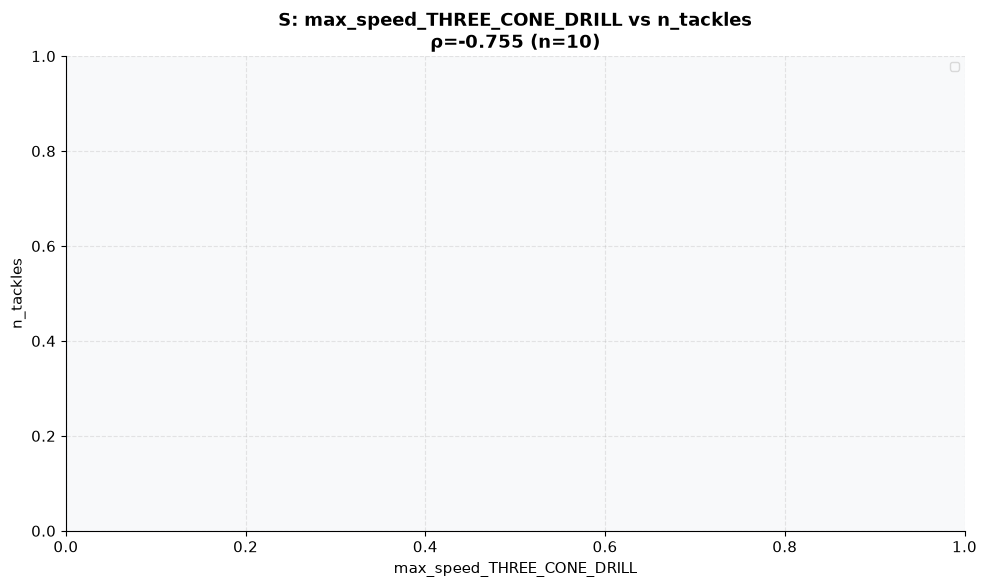

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_S_max_speed_FORTY_YARD_DASH_vs_n_tackles.png


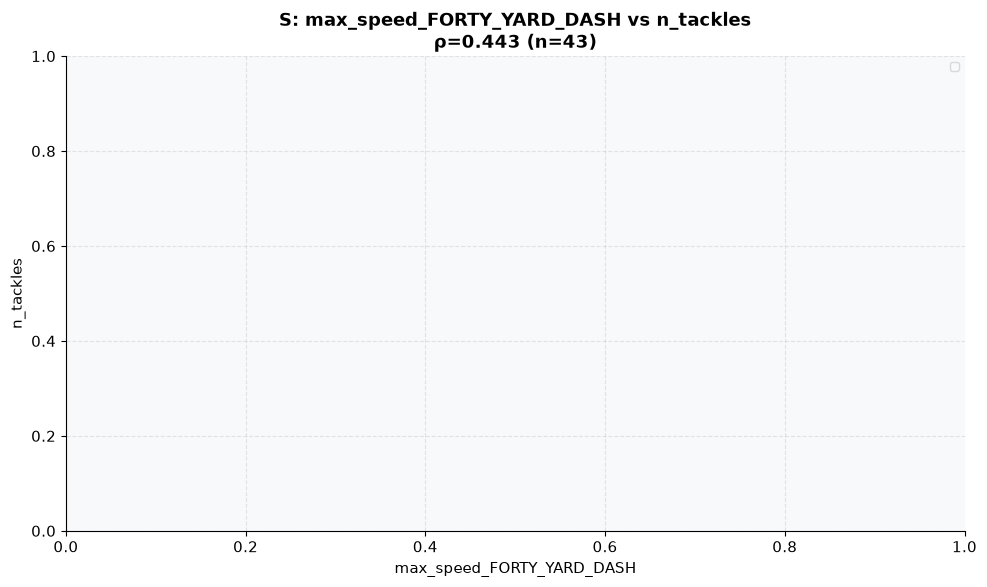

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_S_first_step_acceleration_THREE_CONE_DRILL_vs_n_tackles.png


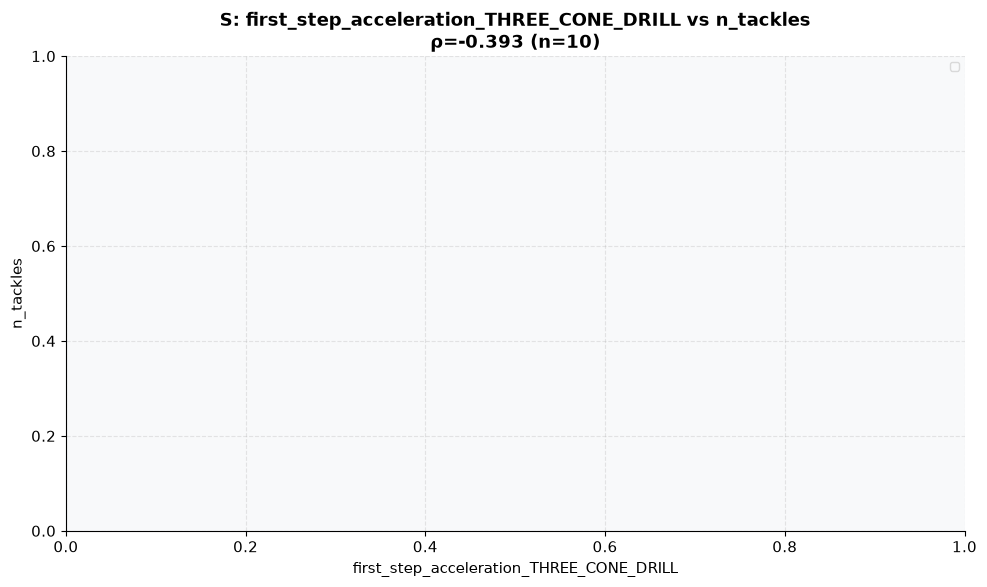

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_WR_direction_change_rate_SHORT_SHUTTLE_vs_mean_separation.png


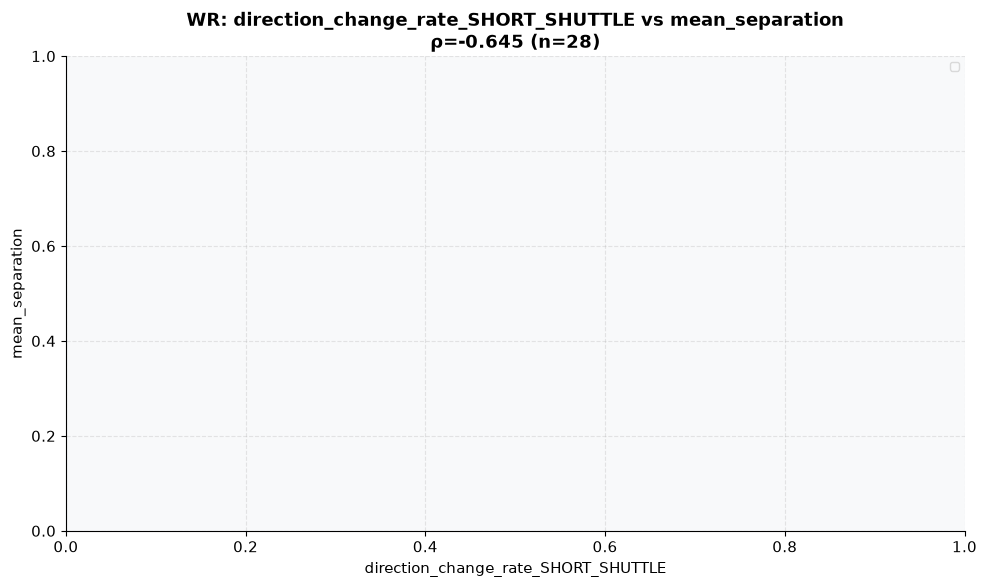

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_WR_direction_change_rate_SHORT_SHUTTLE_vs_median_separation.png


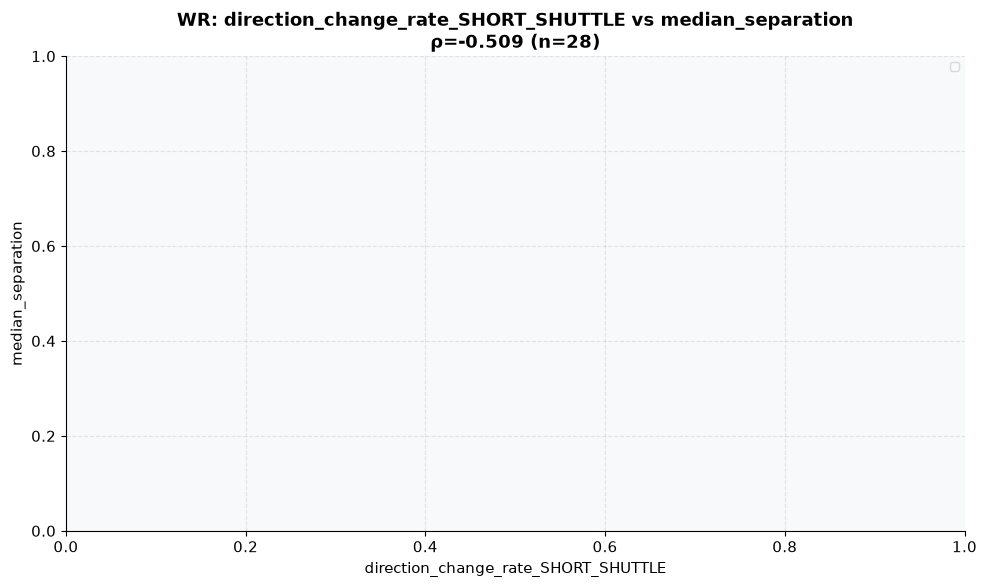

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_WR_time_to_75pct_peak_SHORT_SHUTTLE_vs_mean_separation.png


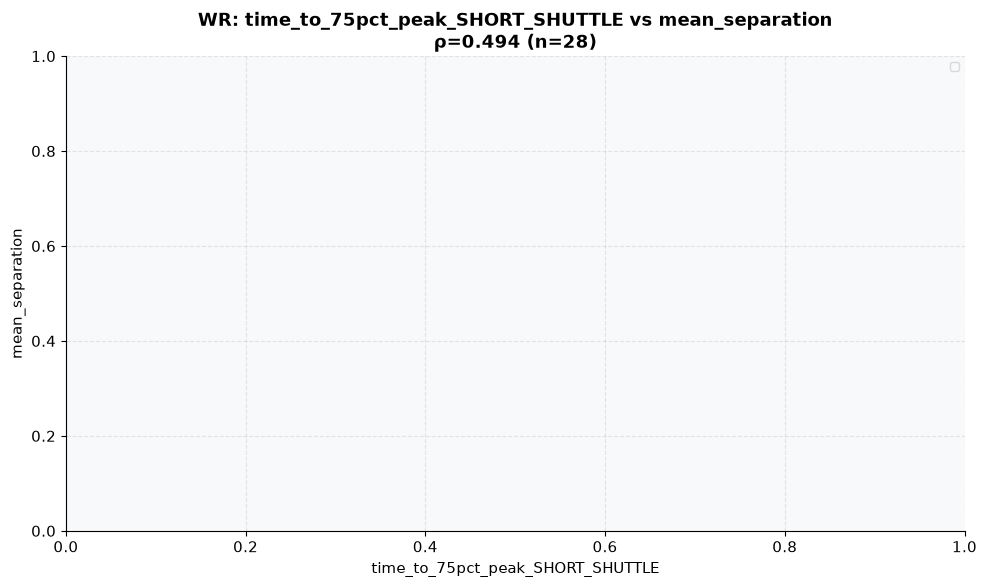

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_WR_time_to_75pct_peak_SHORT_SHUTTLE_vs_median_separation.png


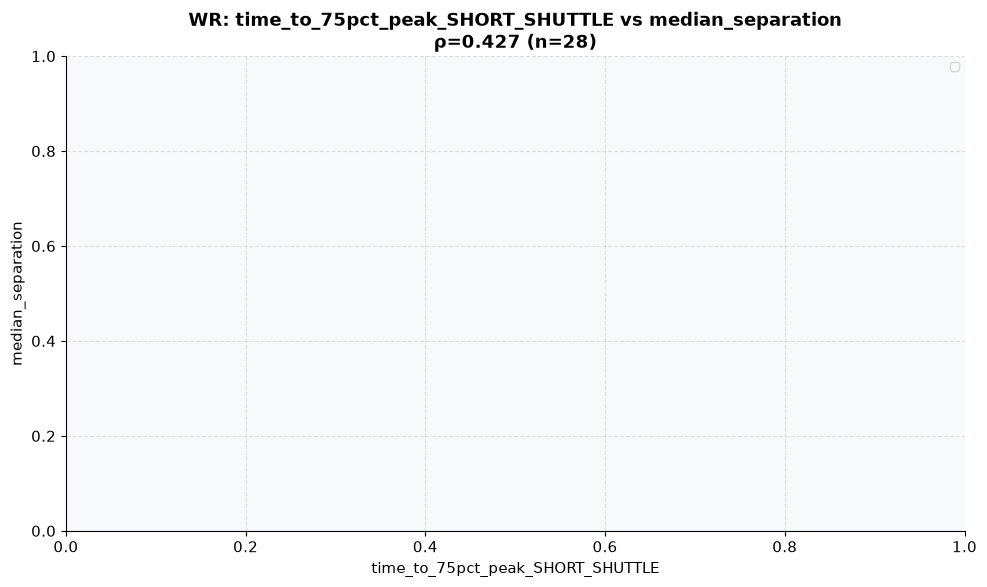

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_WR_time_to_75pct_peak_THREE_CONE_DRILL_vs_target_share.png


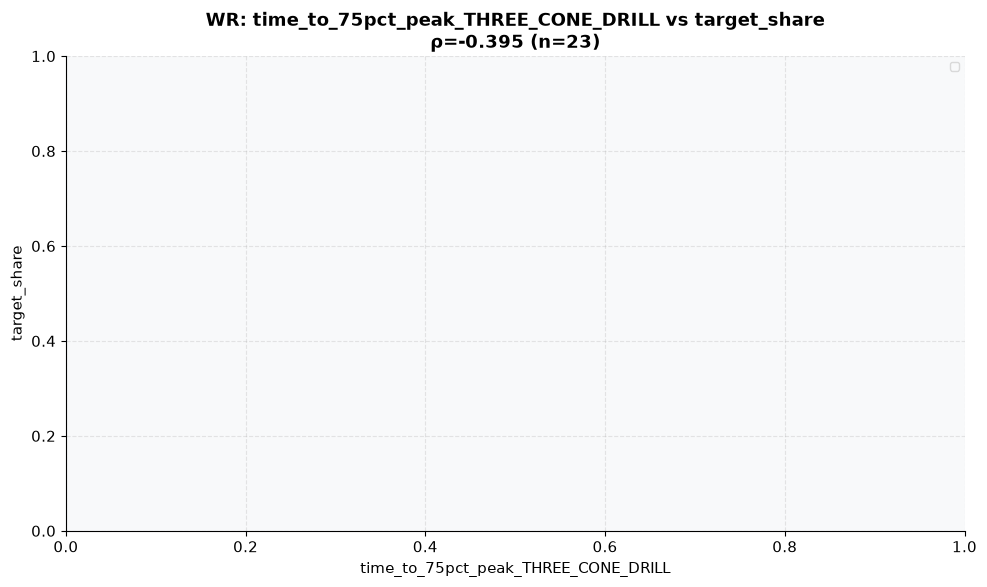

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_TE_time_to_75pct_peak_THREE_CONE_DRILL_vs_target_share.png


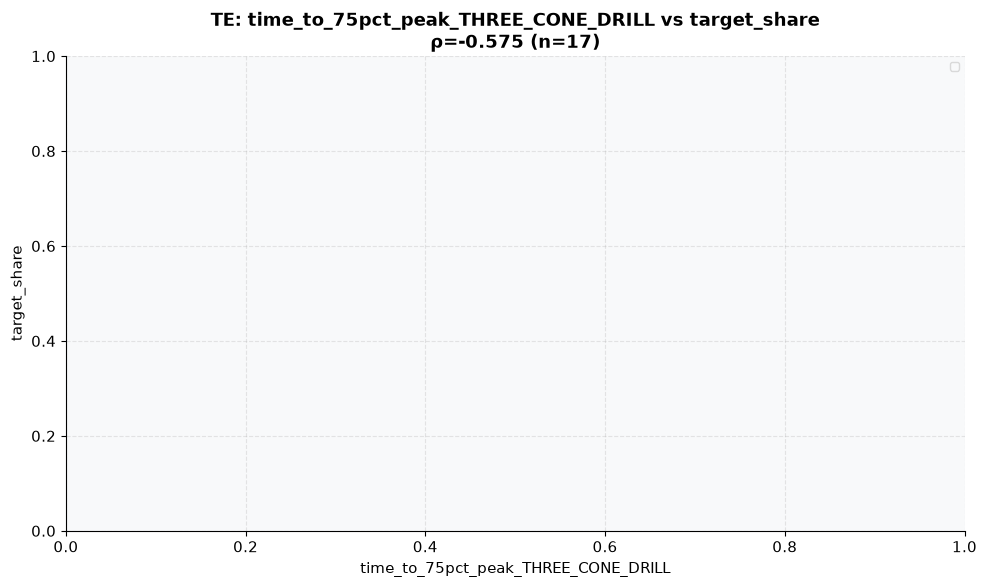

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_TE_first_step_acceleration_SHORT_SHUTTLE_vs_target_share.png


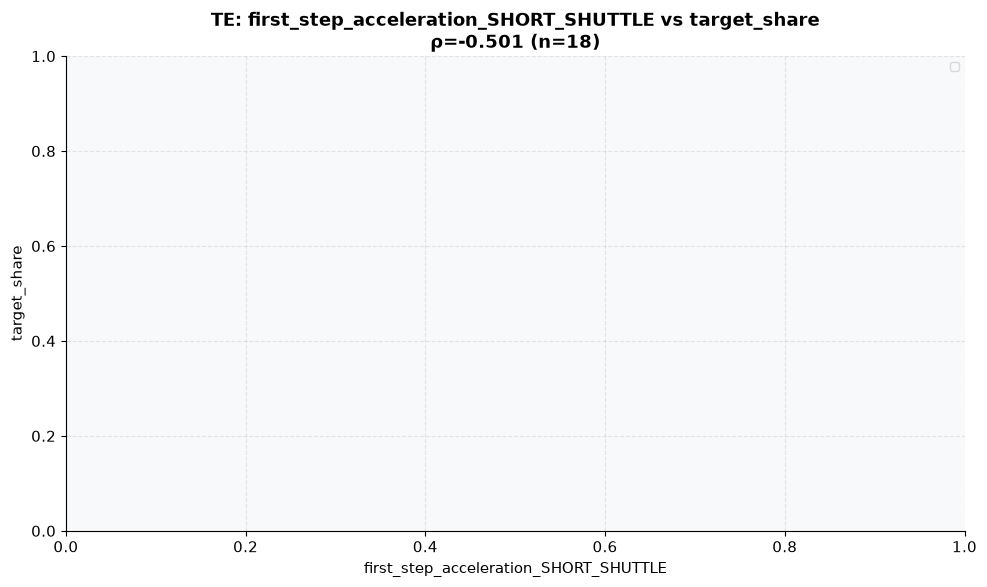

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_TE_burst_impulse_0_5s_SHORT_SHUTTLE_vs_target_share.png


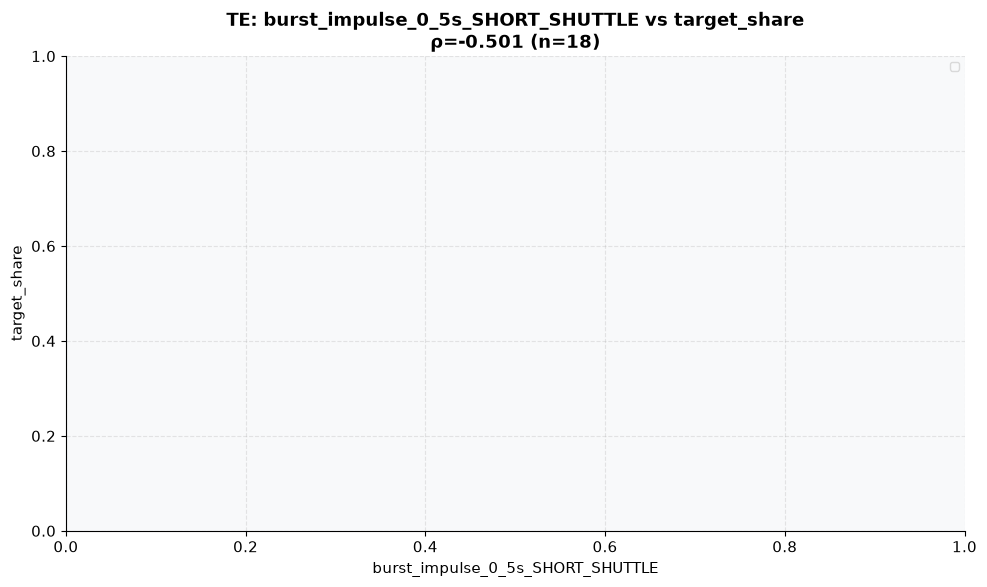

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_TE_burst_impulse_0_1s_THREE_CONE_DRILL_vs_target_share.png


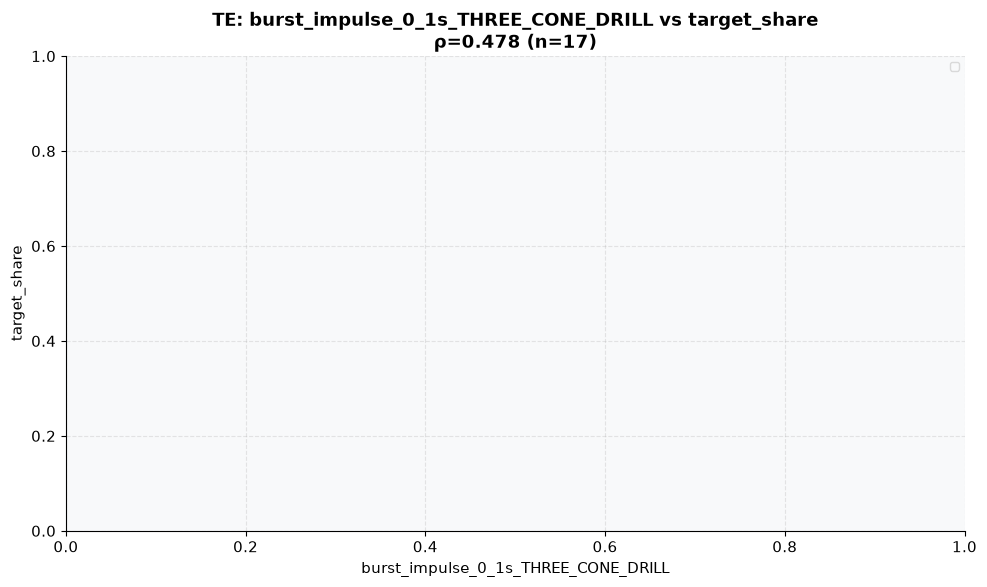

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:473: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.7)
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\scatter_TE_mean_speed_SKILL_DRILLS_TE_vs_target_share.png


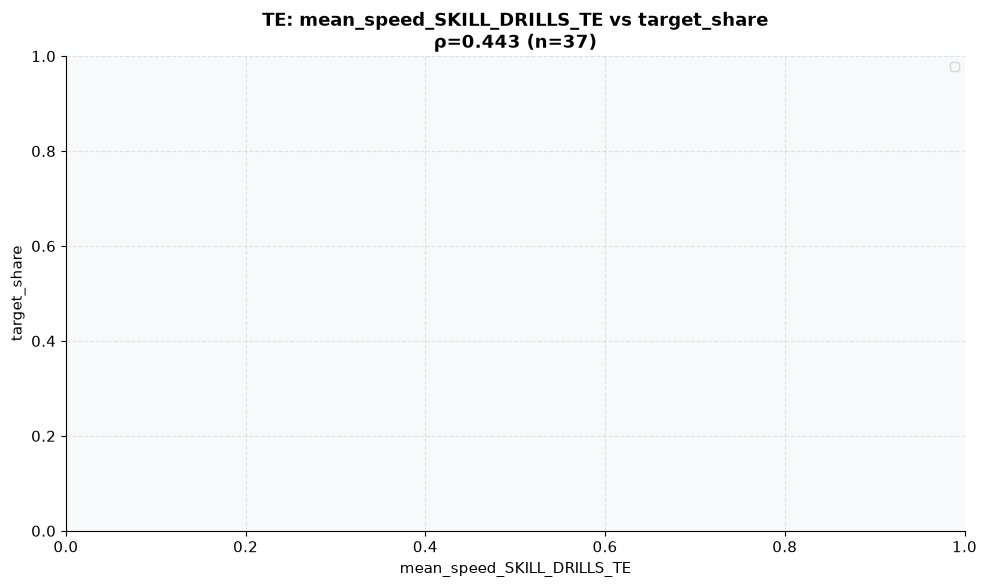

In [10]:
# Combine all correlations into one ranked table
if all_correlations:
    master_corr = pd.concat(all_correlations, ignore_index=True)
    master_corr = master_corr.sort_values('abs_rho', ascending=False)
    
    print('\n=== TOP 20 COMBINE → NFL CORRELATIONS (across all positions) ===')
    display(master_corr.head(20))

    # Save
    master_corr.to_parquet(DATA_PROCESSED / 'correlation_summary.parquet', index=False)
    master_corr.to_csv(TABLES_DIR / 'correlation_summary.csv', index=False)
    print('Saved correlation summary.')

    # Visualize top correlations
    top_pos_groups = master_corr['position_group'].unique()[:3]
    for pos in top_pos_groups:
        pos_corr = master_corr[master_corr['position_group'] == pos].head(5)
        if len(pos_corr) == 0:
            continue
        for _, row in pos_corr.iterrows():
            plot_combine_vs_nfl(
                analysis_df[analysis_df['position_group'] == pos],
                x_col=row['combine_feature'],
                y_col=row['nfl_outcome'],
                title=f'{pos}: {row["combine_feature"]} vs {row["nfl_outcome"]}\nρ={row["rho"]:.3f} (n={row["n"]})',
                filename=f'scatter_{pos}_{row["combine_feature"]}_vs_{row["nfl_outcome"]}.png'.replace('/', '_'),
            )
            plt.show()
else:
    print('NOT YET COMPUTED — no correlations available.')

## 7. Incremental Value: Tracking vs Traditional

Does tracking data add value beyond traditional combine metrics?

In [11]:
if not analysis_df.empty:
    traditional_cols = [c for c in ['ten_yd_split', 'forty', 'vertical', 'broad_jump',
                                     'three_cone', 'short_shuttle', 'ngs_athleticism_score']
                        if c in analysis_df.columns]

    tracking_cols = [c for c in analysis_df.columns
                     if any(c.startswith(f) for f in [
                         'max_speed', 'first_step', 'total_direction', 'best_peak_reaccel',
                         'movement_efficiency', 'direction_change_rate',
                     ])]

    print(f'Traditional features: {traditional_cols}')
    print(f'Tracking features: {len(tracking_cols)}')

    # Test on WR separation as primary target
    if 'mean_separation' in analysis_df.columns and traditional_cols and tracking_cols:
        wr_data = analysis_df[analysis_df['position_group'] == 'WR'].copy()

        if len(wr_data) >= MIN_SAMPLE_SIZE:
            y = wr_data['mean_separation'].values
            xb = wr_data[traditional_cols]
            xf = wr_data[traditional_cols + tracking_cols[:10]]  # limit features

            result = incremental_r_squared(y, xb, xf)
            print(f'\nWR separation — incremental R² analysis:')
            for k, v in result.items():
                print(f'  {k}: {v}')

            plot_model_comparison(
                {
                    'Traditional Only': result.get('r2_baseline', 0),
                    'Traditional + Tracking': result.get('r2_full', 0),
                },
                title='Predicting WR Separation: Traditional vs Tracking-Enhanced',
                filename='model_comparison_wr_separation.png',
            )
            plt.show()
        else:
            print(f'Insufficient WR data for incremental R² analysis (n={len(wr_data)})')
    else:
        print('NOT YET COMPUTED — required columns not available')
else:
    print('Analysis dataset not available.')

Traditional features: []
Tracking features: 45
NOT YET COMPUTED — required columns not available


## 8. Rank Hypothesis Candidates

Synthesize all findings into a ranked list of research directions.

In [12]:
# This cell summarizes hypothesis candidates based on actual data above.
# The template below will be auto-populated where data is available,
# and flagged as NOT YET COMPUTED where it is not.

def format_hypothesis_report(all_correlations_df: pd.DataFrame) -> str:
    """Generate hypothesis candidates markdown from correlation summary."""
    lines = []
    lines.append('# NFL Big Data Bowl 2027 — Hypothesis Candidates')
    lines.append(f'\n*Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}*')
    lines.append('\n> All numbers below come from actual data. Where data was unavailable, "NOT YET COMPUTED" is stated explicitly.\n')

    if all_correlations_df is not None and not all_correlations_df.empty:
        # Get top unique candidates
        top = all_correlations_df.head(10)

        lines.append('## Ranked Correlation Findings')
        lines.append('Ranked by |ρ| (Spearman). Minimum n = 10 players.\n')
        lines.append('| Rank | Position | Combine Feature | NFL Outcome | ρ | n | p-value |')
        lines.append('|------|----------|-----------------|-------------|---|---|---------|')

        for i, row in top.iterrows():
            lines.append(
                f'| {i+1} | {row["position_group"]} | {row["combine_feature"]} | '
                f'{row["nfl_outcome"]} | {row["rho"]:.3f} | {row["n"]} | {row["p_value"]:.4f} |'
            )
    else:
        lines.append('## Ranked Correlation Findings')
        lines.append('\n**NOT YET COMPUTED** — Run all cells above with actual data.')

    lines.append('\n\n## Candidate Hypotheses (Template)')
    lines.append('\nFill in based on actual data findings above.\n')

    hypotheses_template = [
        {
            'rank': 1,
            'hypothesis': 'NOT YET DETERMINED — pending data analysis',
            'position': 'TBD',
            'combine_drill': 'TBD',
            'tracking_metric': 'TBD',
            'nfl_outcome': 'TBD',
            'sample_size': 'TBD',
            'evidence': 'NOT YET COMPUTED',
            'novelty': 'TBD',
            'football_interpretation': 'TBD',
            'potential_confounders': 'draft position, team scheme, snap count, route type',
            'difficulty': 'TBD',
            'competition_potential': 'TBD',
        },
    ]

    # If we have real correlations, populate top candidates
    if all_correlations_df is not None and not all_correlations_df.empty:
        hypotheses_template = []
        top5 = all_correlations_df.head(5)
        for rank, (_, row) in enumerate(top5.iterrows(), 1):
            sig_note = '(statistically significant)' if row['p_value'] < 0.05 else '(not yet significant — needs more data)'
            hypotheses_template.append({
                'rank': rank,
                'hypothesis': (
                    f'{row["combine_feature"]} during Combine drills is associated with '
                    f'{row["nfl_outcome"]} in {row["position_group"]} players'
                ),
                'position': row['position_group'],
                'tracking_metric': row['combine_feature'],
                'nfl_outcome': row['nfl_outcome'],
                'sample_size': row['n'],
                'evidence': f'ρ = {row["rho"]:.3f}, p = {row["p_value"]:.4f} {sig_note}',
                'potential_confounders': 'draft position, team scheme, snap count, opponent quality, position within scheme',
            })

    for hyp in hypotheses_template:
        lines.append(f'\n### Hypothesis #{hyp["rank"]}')
        for key, val in hyp.items():
            if key != 'rank':
                lines.append(f'- **{key.replace("_", " ").title()}**: {val}')

    lines.append('\n\n## Important Caveats')
    lines.append('\n- Correlation ≠ causation. All findings are associations.')
    lines.append('- Sample sizes are small (~510 players). Effect sizes may be unstable.')
    lines.append('- Tracking frames are NOT independent observations. The player is the unit of analysis.')
    lines.append('- Confounders (team, scheme, snap count, opponent) are not yet controlled.')
    lines.append('- First-season performance may not reflect long-term potential.')

    return '\n'.join(lines)


all_corr_df = None
if all_correlations:
    all_corr_df = pd.concat(all_correlations, ignore_index=True).sort_values('abs_rho', ascending=False)

report_text = format_hypothesis_report(all_corr_df)
report_path = REPORTS_DIR / 'hypothesis_candidates.md'
report_path.write_text(report_text, encoding='utf-8')
print(f'Saved: {report_path}')
print()
print(report_text)

Saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\reports\hypothesis_candidates.md

# NFL Big Data Bowl 2027 — Hypothesis Candidates

*Generated: 2026-10-09 22:08*

> All numbers below come from actual data. Where data was unavailable, "NOT YET COMPUTED" is stated explicitly.

## Ranked Correlation Findings
Ranked by |ρ| (Spearman). Minimum n = 10 players.

| Rank | Position | Combine Feature | NFL Outcome | ρ | n | p-value |
|------|----------|-----------------|-------------|---|---|---------|
| 761 | S | mean_speed_THREE_CONE_DRILL | n_tackles | -0.871 | 10 | 0.0010 |
| 762 | S | time_to_75pct_peak_THREE_CONE_DRILL | n_tackles | 0.778 | 10 | 0.0080 |
| 763 | S | max_speed_THREE_CONE_DRILL | n_tackles | -0.755 | 10 | 0.0116 |
| 1 | WR | direction_change_rate_SHORT_SHUTTLE | mean_separation | -0.645 | 28 | 0.0002 |
| 201 | TE | time_to_75pct_peak_THREE_CONE_DRILL | target_share | -0.575 | 17 | 0.0158 |
| 721 | CB | max_speed_SHORT_SHUTTLE | n_tackles | 0.567

## 9. Phase 1 Summary

Fill in after running all cells. Do NOT fabricate values.

In [13]:
print('=== PHASE 1 SUMMARY ===')
print()

# Dataset statistics
print('--- Dataset ---')
if 'players' in dir() and players is not None:
    print(f'Players: {len(players):,}')
if 'player_features' in dir() and not player_features.empty:
    print(f'Combine attempts: {len(player_features):,}')
    if 'drill_type' in player_features.columns:
        print(f'Drills: {player_features["drill_type"].nunique()}')
if 'player_play_first' in dir() and player_play_first is not None and season_col is not None:
    print(f'NFL seasons: {player_play_first[season_col].nunique() if season_col in player_play_first.columns else "N/A"}')
print()

# Most promising
print('--- Most Promising (based on data above) ---')
if all_corr_df is not None and not all_corr_df.empty:
    top_positions = all_corr_df.groupby('position_group')['abs_rho'].max().sort_values(ascending=False).head(3)
    print('\nTop position groups:')
    for i, (pos, rho) in enumerate(top_positions.items(), 1):
        print(f'  {i}. {pos} (max |ρ| = {rho:.3f})')

    top_feats = all_corr_df.groupby('combine_feature')['abs_rho'].max().sort_values(ascending=False).head(5)
    print('\nTop tracking features:')
    for i, (feat, rho) in enumerate(top_feats.items(), 1):
        print(f'  {i}. {feat} (max |ρ| = {rho:.3f})')

    top_outcomes = all_corr_df.groupby('nfl_outcome')['abs_rho'].max().sort_values(ascending=False).head(3)
    print('\nTop NFL outcomes:')
    for i, (out, rho) in enumerate(top_outcomes.items(), 1):
        print(f'  {i}. {out} (max |ρ| = {rho:.3f})')
else:
    print('NOT YET COMPUTED — run all cells above with actual data.')

print('\n--- Recommended Primary Research Direction ---')
print('NOT YET DETERMINED — review hypothesis_candidates.md after running with data.')

=== PHASE 1 SUMMARY ===

--- Dataset ---
Players: 510
Combine attempts: 1,258
Drills: 9
NFL seasons: 3

--- Most Promising (based on data above) ---

Top position groups:
  1. S (max |ρ| = 0.871)
  2. WR (max |ρ| = 0.645)
  3. TE (max |ρ| = 0.575)

Top tracking features:
  1. mean_speed_THREE_CONE_DRILL (max |ρ| = 0.871)
  2. time_to_75pct_peak_THREE_CONE_DRILL (max |ρ| = 0.778)
  3. max_speed_THREE_CONE_DRILL (max |ρ| = 0.755)
  4. direction_change_rate_SHORT_SHUTTLE (max |ρ| = 0.645)
  5. max_speed_SHORT_SHUTTLE (max |ρ| = 0.567)

Top NFL outcomes:
  1. n_tackles (max |ρ| = 0.871)
  2. mean_separation (max |ρ| = 0.645)
  3. target_share (max |ρ| = 0.575)

--- Recommended Primary Research Direction ---
NOT YET DETERMINED — review hypothesis_candidates.md after running with data.
